<h1 style="background-color: transparent; color: #ADD8E6; padding: 10px; text-align: left; font-size: 36px;">
    NETFLIX CUSTOMER CHURN PREDICTION
</h1>

<h1 style="background-color: #ADD8E6; color: white; padding: 10px; border-radius: 5px; text-align: center;">
    INTRODUCTION
</h1>

<h1 style="background-color: transparent; color: #ADD8E6; padding: 10px; text-align: left;">
    BUSINESS GOAL
</h1>

<div style="padding: 15px; margin-top: 10px; color: black;">
The main business goal for the Netflix Customer Churn Prediction project is to proactively protect and stabilize annual revenue by ensuring subscribers stay longer. Instead of waiting for customers to cancel, the system identifies high-risk individuals—primarily those showing low engagement, such as reduced daily watch time—allowing the company to intervene first. By focusing retention efforts solely on these most vulnerable customers, the project aims to achieve a 15% reduction in churn, which directly translates to $42 million in protected annual revenue in real. Ultimately, this shift enables Netflix to increase the average value of its customers and allocate its marketing and content resources far more efficiently.
</div>


<h1 style="background-color: transparent; color: #ADD8E6; padding: 10px; text-align: left;">
    DATA OVERVIEW
</h1>

<div style="padding: 15px; margin-top: 10px; color: black;">
The project utilizes a dataset comprising 5,000 anonymized customer records, with the primary goal being the prediction of the binary churn outcome (retained or churned). The data is well-balanced, meaning approximately 50% of the customers have churned and 50% have been retained, eliminating the need for complex sampling techniques to correct for class imbalance. The features are broadly categorized into three groups: static customer profiles (including age, gender, geographic region, and payment method); subscription details (such as monthly fee and subscription tier); and crucially, behavioral metrics. These behavioral metrics, like the amount of content consumed and the frequency of platform logins, were confirmed by the predictive model to be the most powerful indicators of a customer's intent to leave. Prior to analysis, features were engineered to capture derived concepts, such as value-per-hour consumed**, which combines the subscription cost with usage data, providing a unified metric of a customer's perceived value from the service.
</div>

<h1 style="background-color: transparent; color: #ADD8E6; padding: 10px; text-align: left; font-size: 24px;">
    1. DATA PREPARATION AND CLEANING
</h1>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import joblib

In [2]:
df = pd.read_csv("../data/netflix_customer_churn.csv")
df.head()


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [3]:
df = df.drop("customer_id", axis=1)

In [4]:
# Value metric
df["value_per_hour"] = df["monthly_fee"] / (df["watch_hours"] + 1)

# Inactivity bucket
df["inactivity_category"] = pd.cut(
    df["last_login_days"],
    bins=[-1, 7, 30, 365],
    labels=["Active", "Moderate", "High"]
)

In [5]:
X = df.drop("churned", axis=1)
y = df["churned"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4000, 14)
Test shape: (1000, 14)


In [7]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns

print("Numeric columns:", list(numeric_cols))
print("Categorical columns:", list(categorical_cols))

Numeric columns: ['age', 'watch_hours', 'last_login_days', 'monthly_fee', 'number_of_profiles', 'avg_watch_time_per_day', 'value_per_hour']
Categorical columns: ['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre', 'inactivity_category']


/var/folders/8y/1m_b31jd32q1j0rct6sj78840000gn/T/ipykernel_3563/202971180.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns


In [8]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [9]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [10]:
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]
y_pred = baseline_model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.9978679232452369
Accuracy: 0.988

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       497
           1       0.99      0.99      0.99       503

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



In [11]:
param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2]
}

grid_search = GridSearchCV(
    baseline_model,
    param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)

Best Params: {'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__n_estimators': 300}


In [12]:
best_model = grid_search.best_estimator_

y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

print("Final ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("\nFinal Classification Report:\n")
print(classification_report(y_test, y_pred))


Final ROC-AUC: 0.9990879671668179
Final Accuracy: 0.993

Final Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       497
           1       1.00      0.99      0.99       503

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



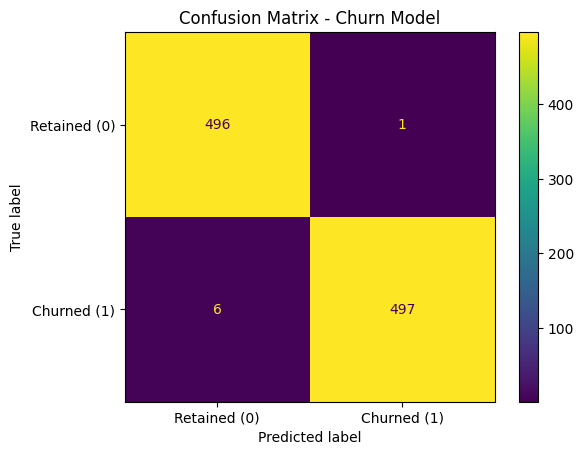

In [13]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Retained (0)", "Churned (1)"])

disp.plot()
plt.title("Confusion Matrix - Churn Model")
plt.show()

In [14]:
import numpy as np

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
5,num__avg_watch_time_per_day,0.638917
1,num__watch_hours,0.090545
4,num__number_of_profiles,0.086649
2,num__last_login_days,0.055413
3,num__monthly_fee,0.054342
30,cat__inactivity_category_High,0.029469
20,cat__payment_method_Crypto,0.018353
22,cat__payment_method_Gift Card,0.012432
6,num__value_per_hour,0.010008
31,cat__inactivity_category_Moderate,0.003472


In [15]:


# Extract feature names from preprocessor
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Extract importance from model
importances = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

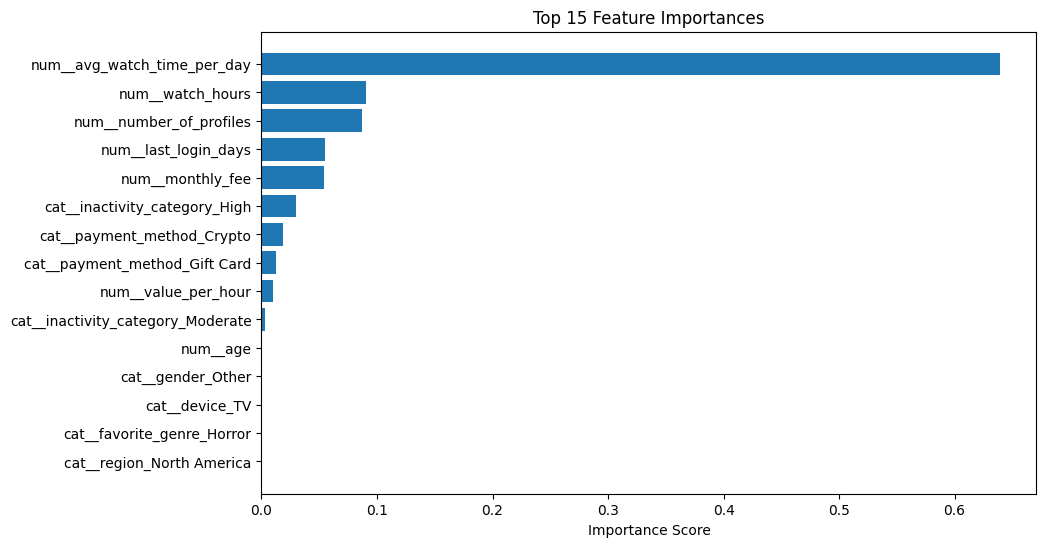

In [16]:
plt.figure(figsize=(10,6))

top_features = importance_df.head(15)

plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.show()

In [17]:
risk_df = X_test.copy()
risk_df["churn_probability"] = y_pred_proba

risk_df["risk_segment"] = pd.cut(
    risk_df["churn_probability"],
    bins=[0, 0.4, 0.7, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

risk_df["risk_segment"].value_counts()

risk_segment
Low Risk       500
High Risk      497
Medium Risk      3
Name: count, dtype: int64

In [18]:
avg_monthly_revenue = df["monthly_fee"].mean()

high_risk_customers = risk_df[risk_df["risk_segment"] == "High Risk"]

estimated_revenue_at_risk = len(high_risk_customers) * avg_monthly_revenue

print("Estimated Monthly Revenue at Risk:", estimated_revenue_at_risk)

Estimated Monthly Revenue at Risk: 6800.649799999998


In [19]:
joblib.dump(best_model, "../models/churn_model.pkl")

['../models/churn_model.pkl']